In [1]:
!pip install git+https://github.com/openai/CLIP.git
!pip install torch torchvision pillow matplotlib scikit-learn

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-7wsr73u0
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-7wsr73u0
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 627.1 kB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=3af3a71c979369d944016a1d5b7d742dc52999612a7cc62027fcbc0aef5b9222
  Stored in directory: /tmp/pip-ephem-wheel-cache-0iw8cimh/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [2]:
import clip
import torch
import numpy as np

from PIL import Image
from pathlib import Path

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model, preprocess = clip.load(
    "ViT-B/32",
    device=device
)

print("Usando:", device)

100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 169MiB/s]


Usando: cpu


In [4]:
from google.colab import files

uploaded = files.upload()

Saving car_1.jpg to car_1.jpg
Saving car_2.jpg to car_2.jpg
Saving car_3.jpg to car_3.jpg
Saving cat_1.webp to cat_1.webp
Saving cat_2.jpg to cat_2.jpg
Saving cat_3.jpg to cat_3.jpg
Saving dog_1.webp to dog_1.webp
Saving dog_2.webp to dog_2.webp
Saving dog_3.webp to dog_3.webp
Saving tree_1.jpg to tree_1.jpg
Saving tree_2.webp to tree_2.webp
Saving tree_3.jpg to tree_3.jpg


In [5]:
import os

image_paths = []

for file_name in os.listdir():
    if file_name.lower().endswith(
        (".jpg", ".jpeg", ".png", "webp")
    ):
        image_paths.append(file_name)

print(f"Encontradas {len(image_paths)} imágenes")

Encontradas 12 imágenes


In [6]:
image_features = []

with torch.no_grad():

    for path in image_paths:

        image = preprocess(
            Image.open(path)
        ).unsqueeze(0).to(device)

        features = model.encode_image(image)

        image_features.append(
            features.cpu().numpy()
        )

X = np.vstack(image_features)

print(X.shape)

(12, 512)


In [7]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

print(X_pca.shape)

(12, 2)


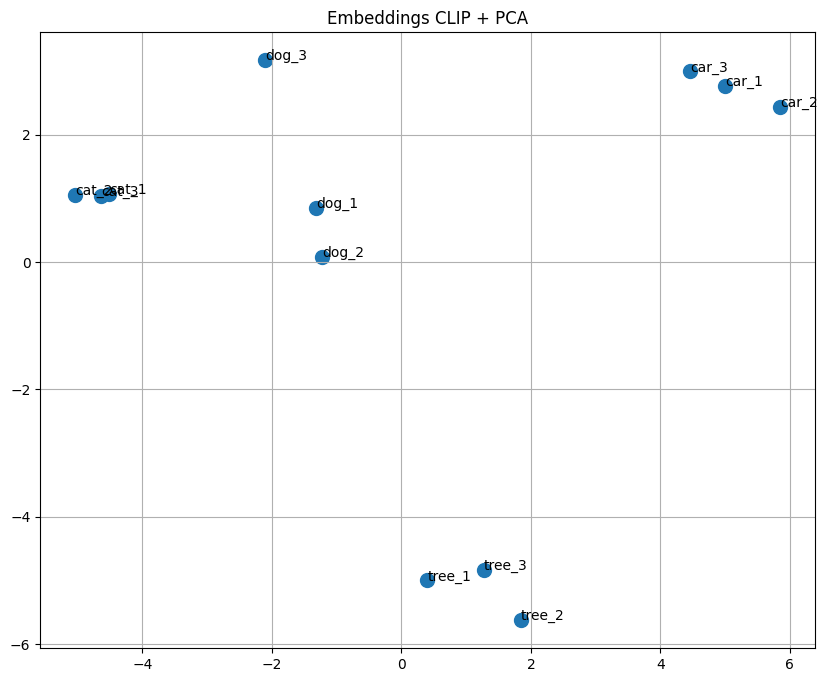

In [8]:
plt.figure(figsize=(10,8))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    s=100
)

for i, path in enumerate(image_paths):

    plt.annotate(
        Path(path).stem,
        (X_pca[i,0], X_pca[i,1])
    )

plt.title("Embeddings CLIP + PCA")
plt.grid(True)

plt.show()

In [9]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

clusters = kmeans.fit_predict(X)

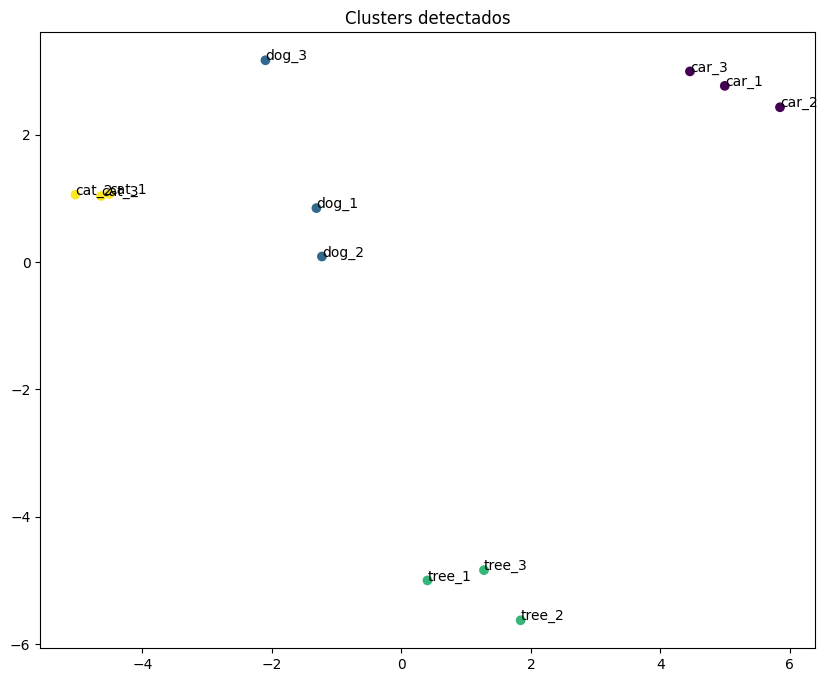

In [10]:
plt.figure(figsize=(10,8))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters
)

for i, path in enumerate(image_paths):

    plt.annotate(
        Path(path).stem,
        (X_pca[i,0], X_pca[i,1])
    )

plt.title("Clusters detectados")
plt.show()

In [11]:
prompts = [
    "a cat",
    "a dog",
    "a car",
    "a tree"
]

text_tokens = clip.tokenize(
    prompts
).to(device)

with torch.no_grad():

    text_features = model.encode_text(
        text_tokens
    )

text_features = text_features.cpu().numpy()

In [12]:
combined = np.vstack([
    X,
    text_features
])

combined_2d = PCA(
    n_components=2
).fit_transform(combined)

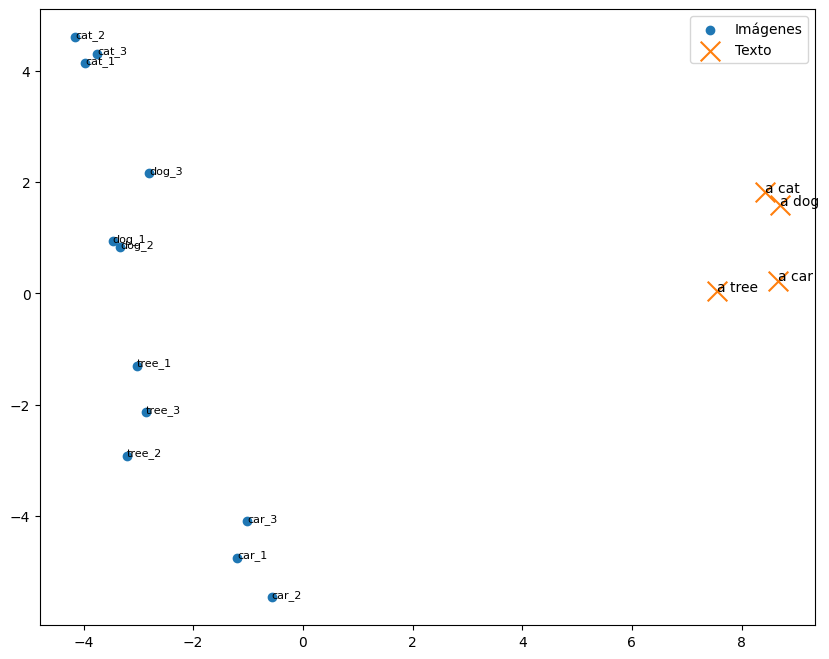

In [13]:
image_features = np.vstack(image_features)

image_features = image_features / np.linalg.norm(
    image_features,
    axis=1,
    keepdims=True
)

text_features = text_features / np.linalg.norm(
    text_features,
    axis=1,
    keepdims=True
)

combined = np.vstack([
    image_features,
    text_features
])

n_images = len(image_paths)

plt.figure(figsize=(10,8))

plt.scatter(
    combined_2d[:n_images,0],
    combined_2d[:n_images,1],
    label="Imágenes"
)

for i, path in enumerate(image_paths):
    plt.annotate(
        Path(path).stem,
        (combined_2d[i,0], combined_2d[i,1]),
        fontsize=8
    )

plt.scatter(
    combined_2d[n_images:,0],
    combined_2d[n_images:,1],
    marker="x",
    s=200,
    label="Texto"
)

for i, prompt in enumerate(prompts):

    idx = n_images + i

    plt.annotate(
        prompt,
        (
            combined_2d[idx,0],
            combined_2d[idx,1]
        )
    )

plt.legend()
plt.show()

In [18]:
import pandas as pd
from pathlib import Path

similarity = image_features @ text_features.T

image_names = [
    Path(path).stem
    for path in image_paths
]

df_similarity = pd.DataFrame(
    similarity,
    index=image_names,
    columns=prompts
)

for i, image_name in enumerate(image_names):

    best_prompt = prompts[np.argmax(similarity[i])]
    score = np.max(similarity[i])

    print(
        f"{image_name:15} -> {best_prompt:10} ({score:.3f})"
    )

tree_1          -> a tree     (0.283)
dog_3           -> a dog      (0.264)
cat_2           -> a cat      (0.271)
tree_3          -> a tree     (0.256)
car_3           -> a car      (0.259)
dog_1           -> a dog      (0.252)
cat_1           -> a cat      (0.278)
cat_3           -> a cat      (0.268)
car_2           -> a car      (0.232)
tree_2          -> a tree     (0.254)
car_1           -> a car      (0.262)
dog_2           -> a dog      (0.270)
